In [1]:
import itertools as iter

import awkward as ak

import dask
import dask_awkward as dak
import hist.dask as hda
import matplotlib.pyplot as plt

# import numba
# import numpy as np
import uproot

# import vector as vec
from coffea.analysis_tools import PackedSelection
from coffea.nanoevents import NanoEventsFactory, ScoutingNanoAODSchema
# from hist import Hist


ModuleNotFoundError: No module named 'dask'

In [2]:
file_list = [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0000.txt").readlines()] # + [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0001.txt").readlines()] + [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0002.txt").readlines()]
file_list = ["root://cmseos.fnal.gov//" + string for string in file_list]



ScoutingNanoAODSchema.warn_missing_crossrefs = False

small_events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list[0:1]},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "HadronicTops"},
).events()

small_events = small_events[:10_000]
#ak.num(small_events, axis=0).compute()

/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/coffea/nanoevents/methods/candidate.py:11: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [3]:
truth = small_events.GenPart[(abs(small_events.GenPart.pdgId) == 24) & ( small_events.GenPart.hasFlags(['isLastCopy','isPrompt']))]

w_to_jets_cut = (abs(truth.distinctChildren[:,:,0].pdgId) == 1) | (abs(truth.distinctChildren[:,:,0].pdgId) == 2) | (abs(truth.distinctChildren[:,:,0].pdgId) == 3) | (abs(truth.distinctChildren[:,:,0].pdgId) == 4)
w_truth = truth[w_to_jets_cut]


good_events = small_events[(ak.num(w_truth, axis=1) > 0)]

w_truth = w_truth[ak.num(w_truth, axis=1) > 0]
w_truth = w_truth[:,0]

truth_b = good_events.GenPart[(abs(good_events.GenPart.pdgId) == 5)\
                                & ( good_events.GenPart.hasFlags(['isLastCopy'])) \
                                 & (good_events.GenPart.distinctParentIdxG == w_truth.distinctParentIdxG)
]
# truth_b = truth_b[ak.num(truth_b, axis=1) > 0]
good_events = good_events[(ak.num(truth_b, axis=1) > 0) & (ak.num(w_truth.distinctChildren, axis=1) > 1)]

In [4]:
truth = good_events.GenPart[(abs(good_events.GenPart.pdgId) == 24) & ( good_events.GenPart.hasFlags(['isLastCopy','isPrompt']))]

w_to_jets_cut = (abs(truth.distinctChildren[:,:,0].pdgId) == 1) | (abs(truth.distinctChildren[:,:,0].pdgId) == 2) | (abs(truth.distinctChildren[:,:,0].pdgId) == 3) | (abs(truth.distinctChildren[:,:,0].pdgId) == 4)

w_truth = truth[w_to_jets_cut]
w_truth = w_truth[ak.num(w_truth, axis=1) > 0]
w_truth = w_truth[:,0]
w_jets_truth = w_truth.distinctChildren
w_jets_truth = w_jets_truth[ak.num(w_jets_truth, axis=1) > 1]

In [11]:
truth_b = good_events.GenPart[(abs(good_events.GenPart.pdgId) == 5) \
                                      & ( good_events.GenPart.hasFlags(['isLastCopy']) ) \
                                       & (good_events.GenPart.distinctParentIdxG == w_truth.distinctParentIdxG) \
        ]


In [12]:
truth_b = truth_b[:,0]
first_jet = w_jets_truth[:,0]
second_jet = w_jets_truth[:,1]

# first_jet.nearest(good_events.ScoutingJet).compute()


candidate_one = good_events.ScoutingJet[ak.local_index(good_events.ScoutingJet,axis=1) == ak.argmin(first_jet.delta_r(good_events.ScoutingJet),axis=1)]
candidate_two = good_events.ScoutingJet[ak.local_index(good_events.ScoutingJet,axis=1) == ak.argmin(second_jet.delta_r(good_events.ScoutingJet),axis=1)]
candidate_b = good_events.ScoutingJet[ak.local_index(good_events.ScoutingJet,axis=1) == ak.argmin(truth_b.delta_r(good_events.ScoutingJet),axis=1)]

w_candidate = candidate_one + candidate_two


h_mass = (
            hda.Hist.new
            .StrCat(["w", "top"], name="object")
            .Log(1000, 30, 500., name="mass", label="Invariant Mass [GeV]")
            .Weight()
        )

top_candidate = w_candidate + candidate_b

w_candidate = w_candidate[:,0]
top_candidate = top_candidate[:,0]

h_mass.fill(object="w", mass=w_candidate.mass)
h_mass.fill(object="top", mass=top_candidate.mass)


Hist(
  StrCategory(['w', 'top'], name='object'),
  Regular(1000, 30, 500, transform=log, name='mass', label='Invariant Mass [GeV]'),
  storage=Weight()) # Sum: WeightedSum(value=0, variance=0) (has staged fills)

In [13]:
my_hist = h_mass.compute()

In [33]:
my_hist["w",:]

Hist(Regular(1000, 30, 500, transform=log, name='mass', label='Invariant Mass [GeV]'), storage=Weight()) # Sum: WeightedSum(value=9496, variance=9496) (WeightedSum(value=9943, variance=9943) with flow)

In [36]:
file = uproot.recreate("test2.root")
file["w_mass"] = my_hist["w",:]
file["top_mass"] = my_hist["top",:]


In [37]:
file.close()

In [37]:
ak.argmin(first_jet.delta_r(small_events.ScoutingJet),axis=1).compute()

<Array [3, 0, 3, 2, 6, 2, 1, 0, ..., 5, 4, 2, 1, 2, 2, 2, 2] type='30 * ?int64'>

In [17]:
parts = small_events.GenPart
cut = (parts.pdgId == -11) | (parts.pdgId == 11) 

val = ak.sum(ak.num(parts[cut].pdgId,axis=1) > 0) / ak.num(parts,axis=0)

val.compute()

0.9624712564611545

In [9]:
small_events.ScoutingJet.particleNet_prob_b.compute()

<Array [[1.2e-24, 0, 2.82e-25, ..., 0, 0], ...] type='610572 * var * float3...'>

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


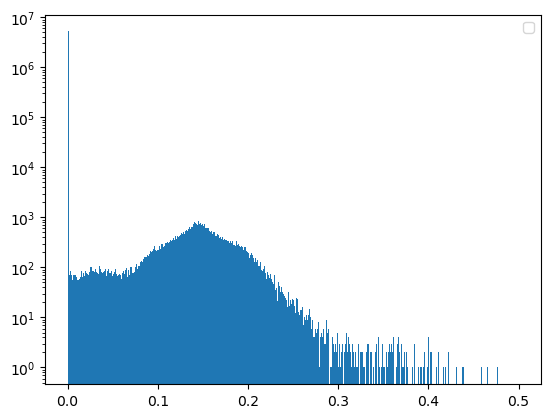

In [5]:
plt.hist(
    ak.flatten(small_events.ScoutingJet.particleNet_prob_b).compute(),
    bins= 500,
    range=(0,0.5),
    )

#y axis is in pico-barns, need to multiply by luminosity to get num events
#lum in inverse pico-barns
plt.yscale("log")
plt.legend()

In [8]:
ak.num(small_events, axis=0).compute()

610572

In [11]:
cut = (ak.num(small_events.ScoutingJet) >= 4) & (small_events.ScoutingMET.pt > 40) & (ak.sum(small_events.ScoutingJet.particleNet_prob_b < 0.001 ,axis=1) > 1)
w_jet_cut = small_events[cut].ScoutingJet.particleNet_prob_b < 0.001 
non_b_jets = small_events[cut].ScoutingJet[w_jet_cut]
w_candidate = non_b_jets[:,0] + non_b_jets[:,1]

w_candidate.mass.compute()

<Array [121, 331, 162, 415, ..., 328, 238, 229, 279] type='434270 * float32'>

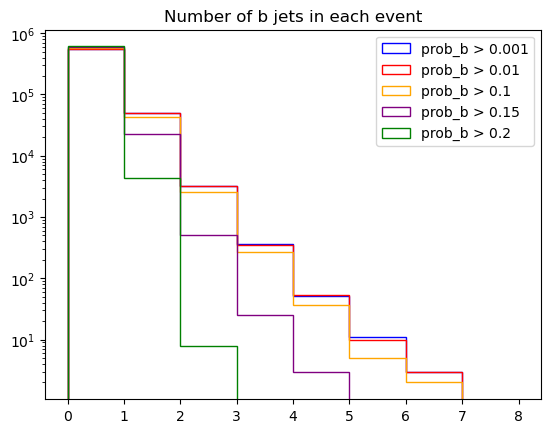

In [6]:
#cut_ev = small_events[(ak.num(small_events.ScoutingJet) >= 4)]

plt.hist(
    ak.sum(small_events.ScoutingJet.particleNet_prob_b > 0.001 ,axis=1).compute(),
    bins= 8,
    range=(0,8),
    histtype="step",
    color="blue",
    label="prob_b > 0.001",
    )
plt.hist(
    ak.sum(small_events.ScoutingJet.particleNet_prob_b > 0.01 ,axis=1).compute(),
    bins= 8,
    range=(0,8),
    histtype="step",
    color="red",
    label="prob_b > 0.01",
    )
plt.hist(
    ak.sum(small_events.ScoutingJet.particleNet_prob_b > 0.1 ,axis=1).compute(),
    bins= 8,
    range=(0,8),
    histtype="step",
    color="orange",
    label="prob_b > 0.1",
    )
plt.hist(
    ak.sum(small_events.ScoutingJet.particleNet_prob_b > 0.15, axis=1).compute(),
    bins= 8,
    range=(0,8),
    histtype="step",
    color="purple",
    label="prob_b > 0.15",
    )
plt.hist(
    ak.sum(small_events.ScoutingJet.particleNet_prob_b > 0.2 ,axis=1).compute(),
    bins= 8,
    range=(0,8),
    histtype="step",
    color="green",
    label="prob_b > 0.2",
    )


#y axis is in pico-barns, need to multiply by luminosity to get num events
#lum in inverse pico-barns
plt.title("Number of b jets in each event")
plt.legend()
plt.yscale("log")